---
title: "Using Classification to Build a Marketing Target Model"
jupyter: python3
---

This lab analyzes the Portuguese Bank Marketing Dataset and develops a classification model to help prioritize marketing calls. The analysis follows the DATA 622 Fall 2026 [Lab 3 assignment](https://georgehagstrom.github.io/DATA622Fall2026/assignments/labs/lab3.html). The course dataset is downloaded into this lab's `datasource/` folder.

In [41]:
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

DATA_DIR = Path("datasource")
DATA_DIR.mkdir(parents=True, exist_ok=True)

RAW_BASE = "https://raw.githubusercontent.com/georgehagstrom/DATA622Fall2026/main/website/assignments/labs/labData"
DATA_URLS = {
    "bank_marketing_dataset.csv": f"{RAW_BASE}/bank_marketing_dataset.csv",
}

for filename, url in DATA_URLS.items():
    destination = DATA_DIR / filename
    if not destination.exists():
        destination.write_bytes(urlopen(url).read())
    print(f"ready: {destination}")

ready: datasource\bank_marketing_dataset.csv


## Problem 1: What Can Machine Learning Do?

The Kaggle notebook uses `duration`, the length of a call, to predict whether a client subscribed. But duration is only known after the call ends, so it cannot help decide whom to call. Including it makes the model's results misleading for choosing clients before a call.

## Problem 2: EDA and Baseline Model

### 2a. EDA Summary and Temporal Patterns

This section loads the course dataset and checks its structure. The CSV includes a saved row index, which is removed because it is not a customer feature. The target `y` records whether the client subscribed to a term deposit.

In [42]:
data_path = DATA_DIR / "bank_marketing_dataset.csv"
bank = pd.read_csv(data_path)
bank = bank.loc[:, ~bank.columns.str.match(r"^Unnamed")].copy()

required_columns = {"y", "year", "month_numeric", "duration"}
missing_columns = required_columns.difference(bank.columns)
if missing_columns:
    raise ValueError(f"Course dataset is missing expected columns: {sorted(missing_columns)}")

bank["subscribed"] = bank["y"].map({"yes": 1, "no": 0})
if bank["subscribed"].isna().any():
    raise ValueError("Unexpected values found in target column 'y'.")

print(f"Rows: {len(bank):,}; columns: {bank.shape[1]:,}")
display(bank.head())
display(bank.describe(include="all").T)

Rows: 45,211; columns: 24


,age,job,marital,education,default,balance,housing,loan,contact,day,...,poutcome,month_numeric,year,euribor3m,emp.var.rate,nr.employed,cons.price.idx,cons.conf.idx,y,subscribed
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


Start by checking the target balance and how both the subscription rate and the number of observed calls change over time. These patterns will guide the choice of test split and evaluation slices.

Target counts:


,count
y,
no,39922
yes,5289


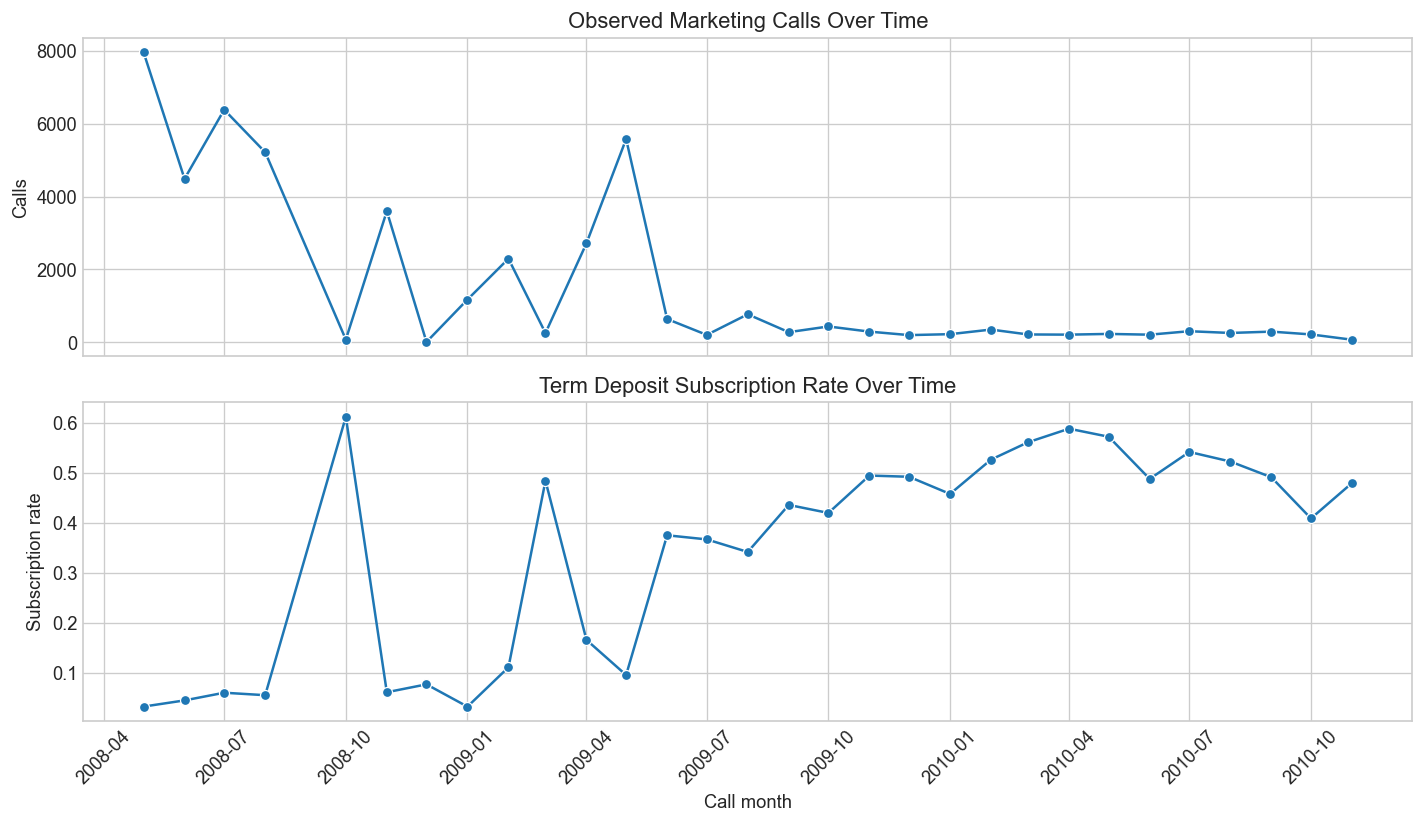

In [43]:
bank["year_month"] = pd.to_datetime(
    bank["year"].astype("int64").astype(str)
    + "-"
    + bank["month_numeric"].astype("int64").astype(str).str.zfill(2)
)

print("Target counts:")
display(bank["y"].value_counts(dropna=False).rename_axis("y").to_frame("count"))

monthly = (
    bank.groupby("year_month", as_index=False)
    .agg(calls=("subscribed", "size"), success_rate=("subscribed", "mean"))
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
sns.lineplot(data=monthly, x="year_month", y="calls", marker="o", ax=axes[0])
axes[0].set(title="Observed Marketing Calls Over Time", xlabel="", ylabel="Calls")
sns.lineplot(data=monthly, x="year_month", y="success_rate", marker="o", ax=axes[1])
axes[1].set(title="Term Deposit Subscription Rate Over Time", xlabel="Call month", ylabel="Subscription rate")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**How to read the plots**

The upper plot shows the number of recorded calls in each month. The lower plot shows the monthly subscription rate: the share of clients marked `yes` out of all recorded calls that month. Because `subscribed` is coded as 1 for yes and 0 for no, its monthly average is that proportion. For example, a rate of 0.60 means 60% of recorded clients subscribed; it does not mean 60 clients. Check the call count above it, since rates from months with few calls can vary sharply.

In [44]:
year_summary = bank.groupby("year", as_index=False).agg(
    calls=("subscribed", "size"),
    subscription_rate=("subscribed", "mean"),
    average_employment_rate=("emp.var.rate", "mean"),
    average_euribor_rate=("euribor3m", "mean"),
    average_employment_count=("nr.employed", "mean"),
    average_consumer_confidence=("cons.conf.idx", "mean"),
)
peak_month = monthly.loc[monthly["calls"].idxmax()]
lowest_month = monthly.loc[monthly["calls"].idxmin()]
print(
    f"Observed period: {monthly['year_month'].min():%Y-%m} to "
    f"{monthly['year_month'].max():%Y-%m}"
)
print(
    f"Highest call volume: {peak_month['calls']:,} in "
    f"{peak_month['year_month']:%Y-%m}; lowest: {lowest_month['calls']:,} in "
    f"{lowest_month['year_month']:%Y-%m}"
)
display(
    year_summary.style.format(
        {
            "subscription_rate": "{:.1%}",
            "average_employment_rate": "{:.2f}",
            "average_euribor_rate": "{:.2f}",
            "average_employment_count": "{:.1f}",
            "average_consumer_confidence": "{:.1f}",
        }
    )
)

Observed period: 2008-05 to 2010-11
Highest call volume: 7,957 in 2008-05; lowest: 13 in 2008-12


,year,calls,subscription_rate,average_employment_rate,average_euribor_rate,average_employment_count,average_consumer_confidence
0,2008,27729,5.1%,1.11,4.89,5213.1,-39.4
1,2009,14862,17.1%,-2.05,1.62,5090.0,-44.3
2,2010,2620,51.6%,-1.61,0.77,4993.4,-38.5


In [50]:
composition_data = bank.assign(
    age_over_55=bank["age"].ge(55),
    blue_collar=bank["job"].eq("blue-collar"),
    housing_loan=bank["housing"].eq("yes"),
    personal_loan=bank["loan"].eq("yes"),
    previously_contacted=bank["previous"].gt(0),
    prior_campaign_success=bank["poutcome"].eq("success"),
    contact_unknown=bank["contact"].eq("unknown"),
)
composition_by_year = composition_data.groupby("year", as_index=False).agg(
    calls=("subscribed", "size"),
    average_age=("age", "mean"),
    age_55_plus_share=("age_over_55", "mean"),
    blue_collar_share=("blue_collar", "mean"),
    housing_loan_share=("housing_loan", "mean"),
    personal_loan_share=("personal_loan", "mean"),
    previously_contacted_share=("previously_contacted", "mean"),
    prior_campaign_success_share=("prior_campaign_success", "mean"),
    contact_unknown_share=("contact_unknown", "mean"),
)
display(
    composition_by_year.style.format(
        {
            "average_age": "{:.1f}",
            "age_55_plus_share": "{:.1%}",
            "blue_collar_share": "{:.1%}",
            "housing_loan_share": "{:.1%}",
            "personal_loan_share": "{:.1%}",
            "previously_contacted_share": "{:.1%}",
            "prior_campaign_success_share": "{:.1%}",
            "contact_unknown_share": "{:.1%}",
        }
    )
)

,year,calls,average_age,age_55_plus_share,blue_collar_share,housing_loan_share,personal_loan_share,previously_contacted_share,prior_campaign_success_share,contact_unknown_share
0,2008,27729,41.3,11.5%,22.9%,55.8%,18.7%,3.3%,0.2%,46.0%
1,2009,14862,39.9,12.5%,21.4%,61.2%,12.7%,37.8%,4.8%,0.0%
2,2010,2620,43.4,25.6%,7.6%,20.9%,6.2%,65.7%,28.7%,9.6%


**How to read the annual summaries**

The first table groups calls by calendar year. `calls` is the number of records, `subscription_rate` is the share with a “yes” outcome, and the remaining columns are yearly averages for employment, Euribor, and consumer confidence indicators. The second table describes the composition of the called client records in each year. Its shares are not estimates for the whole bank customer base. For example, the share with a previous campaign contact rises from 3.3% in 2008 to 37.8% in 2009 and 65.7% in the partial 2010 sample. The share with a prior campaign success rises from 0.2% to 4.8% and 28.7%. This pattern is consistent with increasing repeat targeting, but the changes could also reflect sample or recording differences. The 2010 rows cover only January through November.

Unknown category and null check:


,variable,unknown_count,missing_count,share_unknown_or_missing,unknown_subscription_rate,known_subscription_rate
0,job,288,0,0.6%,11.8%,11.7%
1,education,1857,0,4.1%,13.6%,11.6%
2,contact,13020,0,28.8%,4.1%,14.8%
3,poutcome,36959,0,81.7%,9.2%,23.1%


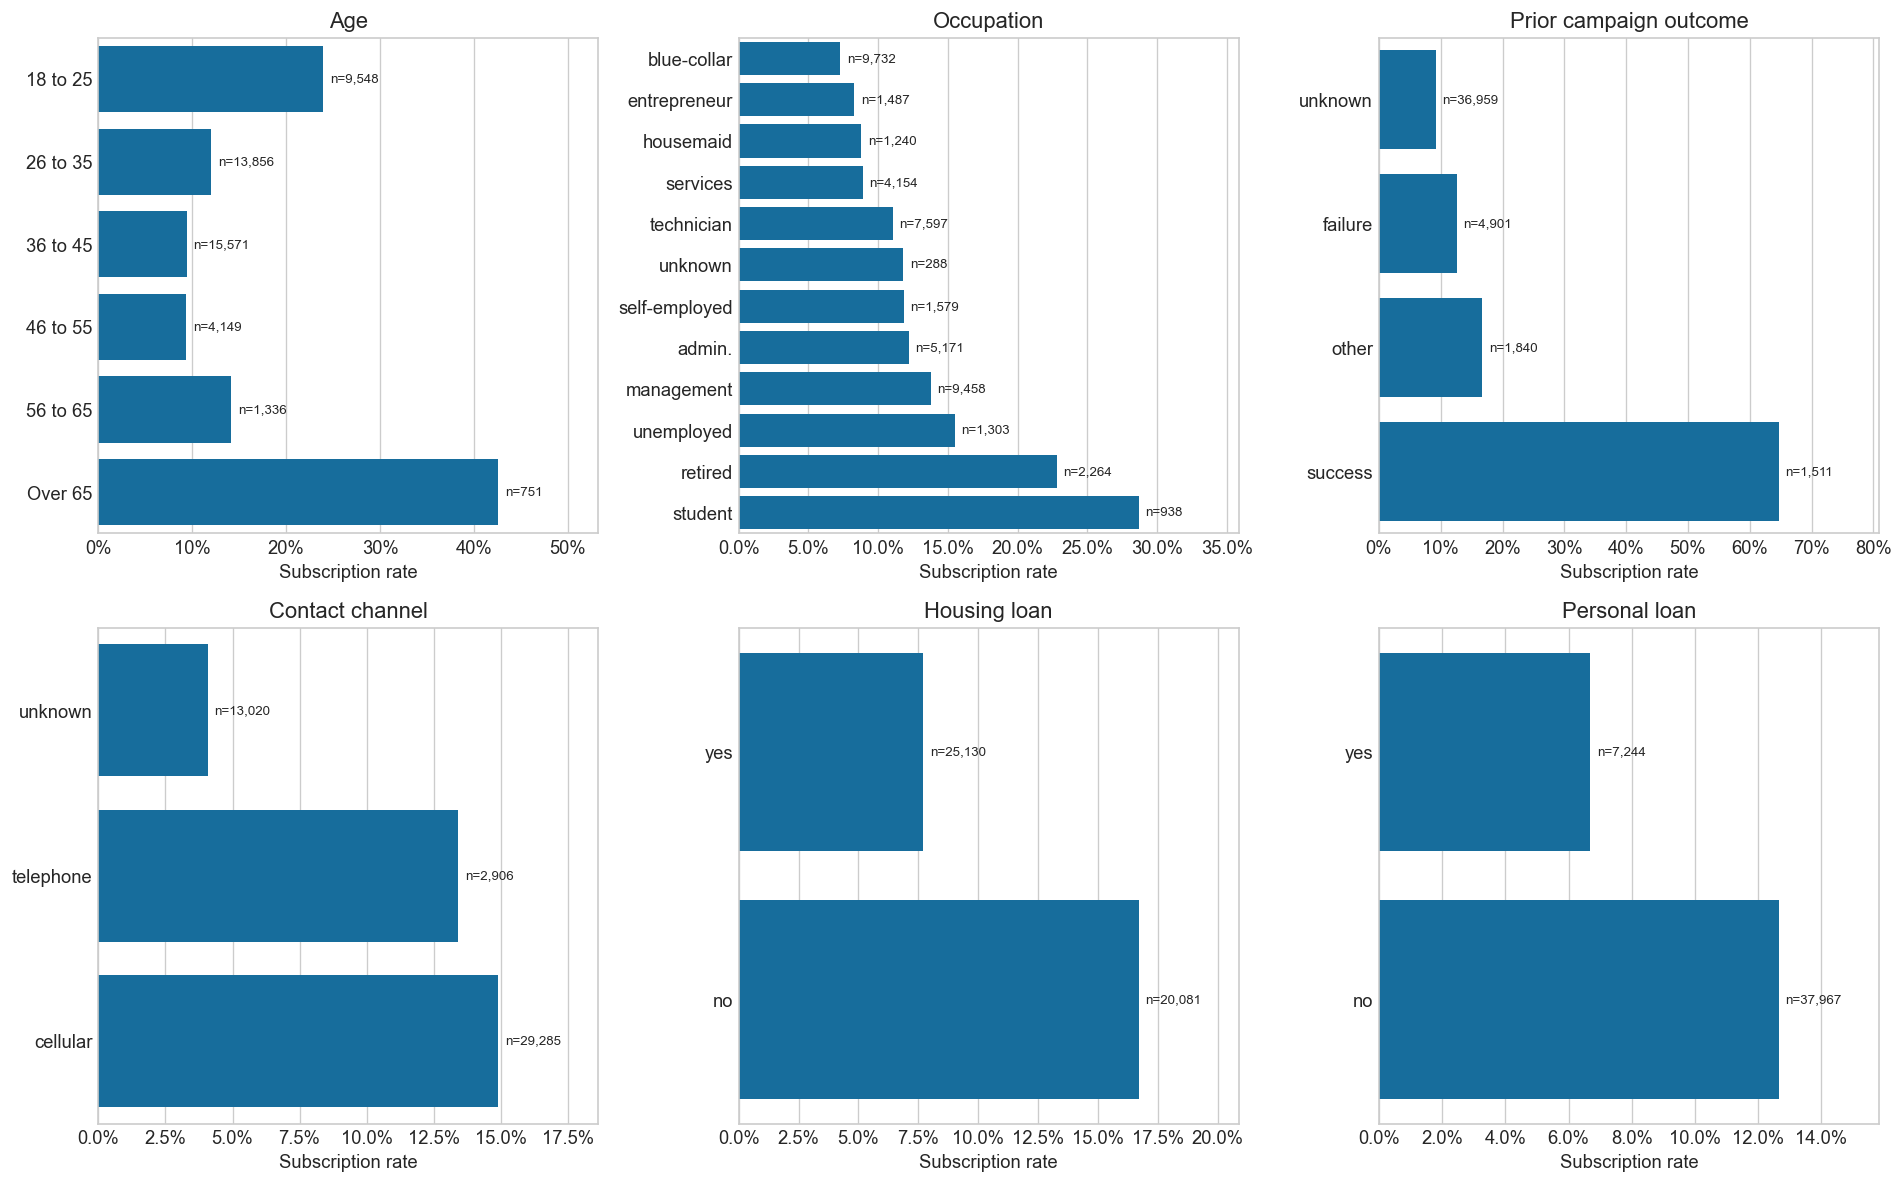

In [45]:
from matplotlib.ticker import PercentFormatter

eda_data = bank.copy()
eda_data["age_band"] = pd.cut(
    eda_data["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18 to 25", "26 to 35", "36 to 45", "46 to 55", "56 to 65", "Over 65"],
)

unknown_rows = []
for column in bank.select_dtypes(include="object").columns.drop("y"):
    unknown_mask = bank[column].astype("string").str.lower().eq("unknown").fillna(False)
    missing_mask = bank[column].isna()
    excluded_mask = unknown_mask | missing_mask
    unknown_count = int(unknown_mask.sum())
    missing_count = int(missing_mask.sum())
    if excluded_mask.any():
        unknown_rows.append(
            {
                "variable": column,
                "unknown_count": unknown_count,
                "missing_count": missing_count,
                "share_unknown_or_missing": excluded_mask.mean(),
                "unknown_subscription_rate": bank.loc[unknown_mask, "subscribed"].mean(),
                "known_subscription_rate": bank.loc[~excluded_mask, "subscribed"].mean(),
            }
        )

print("Unknown category and null check:")
unknown_summary = pd.DataFrame(unknown_rows)
display(
    unknown_summary.style.format(
        {
            "share_unknown_or_missing": "{:.1%}",
            "unknown_subscription_rate": "{:.1%}",
            "known_subscription_rate": "{:.1%}",
        }
    )
)

plot_columns = ["age_band", "job", "poutcome", "contact", "housing", "loan"]
plot_titles = ["Age", "Occupation", "Prior campaign outcome", "Contact channel", "Housing loan", "Personal loan"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for axis, column, title in zip(axes.flat, plot_columns, plot_titles):
    relationship = (
        eda_data.groupby(column, observed=True, dropna=False)
        .agg(clients=("subscribed", "size"), subscription_rate=("subscribed", "mean"))
        .reset_index()
        .sort_values("subscription_rate")
    )
    sns.barplot(data=relationship, x="subscription_rate", y=column, ax=axis, color=sns.color_palette("colorblind")[0])
    for bar, count in zip(axis.patches, relationship["clients"]):
        axis.annotate(
            f"n={count:,}",
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            fontsize=8,
        )
    axis.set(
        title=title,
        xlabel="Subscription rate",
        ylabel="",
        xlim=(0, max(0.1, relationship["subscription_rate"].max() * 1.25)),
    )
    axis.xaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

The chart shows subscription rates for the clients in this dataset. Prior campaign outcome has the largest difference: 64.7% of clients with a previous success subscribed, compared with 12.6% after a previous failure and 9.2% when the outcome was unknown. The rate is also high for clients over 65 (about 42%) and students (about 29%), though those groups have fewer records than many others. Clients without a housing or personal loan subscribed more often than clients with those loans. The rates for cellular and telephone contact are closer, while the unknown contact group has a lower rate. The labels show the number of records in each group, which is useful context when comparing rates. These results describe clients who were called; they do not show that a client’s age, job, or loan status caused a subscription.

In [46]:
null_counts = bank.isna().sum()
if null_counts.sum():
    display(null_counts[null_counts.gt(0)].rename("missing_values").to_frame())
else:
    print("No actual null values are present in the loaded data.")

No actual null values are present in the loaded data.


### 2a. EDA Summary and Temporal Patterns

Of 45,211 clients, 11.7% subscribed, so accuracy alone can be misleading. Subscription rates changed from 5.1% in 2008 to 17.1% in 2009 and 51.6% in January to November 2010. The 2010 sample is smaller and covers only part of the year. Economic indicators also changed, but these records cannot show that they caused the changes in subscription rates.

The clients called also changed over time. The share with an earlier campaign contact rose from 3.3% in 2008 to 65.7% in the partial 2010 sample; the share with an earlier campaign success rose from 0.2% to 28.7%. The charts show different subscription rates by prior outcome, age, job, loan status, and contact channel. Since the dataset includes only clients who were called, these patterns do not explain what would happen to people who were not called. Values recorded as `unknown` are kept as categories.

**Training and test split**

Use a random 75% training and 25% test split, stratified by subscription outcome, with a fixed seed. This keeps the class balance similar in both sets. The time slices come from the test set, but every period also appears in training, so they compare periods in this dataset rather than measure performance on future data.

### 2b. Baseline Logistic Regression

EDA suggests that client profile fields, prior campaign history, and economic indicators may help rank subscription responses. The model uses those fields when they are available before lead selection. Numeric fields are imputed with the median and scaled; categorical fields are imputed with the most common category and one hot encoded. There are no actual null values in this dataset, so imputation is a safeguard for future data. Values marked `unknown` remain their own category.

The model excludes the target fields, `duration`, and `campaign`, because they are only known after a call or after repeat calls have already been made. It also excludes `month`, `month_numeric`, `day`, `year`, and `year_month` so calendar timing does not drive the targeting score. The `contact` field is excluded because it records the channel used for calls in this dataset, not a channel known for every potential lead before selection. The `year_month` field is used only to make test slices, not as a predictor.

On the full test set, ROC AUC is 0.787, the error rate at a 0.5 probability threshold is 10.2%, and the Brier score is 0.080. AUC measures how well the model ranks subscribers above nonsubscribers; the calibration plot compares predicted probabilities with observed subscription rates. These are predictive measures for the selected clients represented in this dataset. They do not estimate the causal effect of calling a lead, and they may not transfer to people the bank did not call.

### 2c. Data Drift

A single test score hides important period differences. The subscription rate rises from 3.6% in the first test slice to 28.2% in the fourth, while slice AUC ranges from 0.531 to 0.807. The client mix, economic conditions, call volume, and selection strategy may all change over time. Since the test set contains more records from some periods than others, the full test score is a weighted average and can hide weak performance in a particular period. The random split also lets training include records from every period, so these slices describe differences within the observed dates rather than performance on future dates.

### 2d. Slice Evaluation

The test set is divided into four consecutive date ranges. Error rate uses a 0.5 probability threshold. Brier score summarizes probability error, with lower values indicating better probability predictions.

| Test data | Period | Size | Subscription rate | Error rate | ROC AUC | Brier score |
|---|---|---:|---:|---:|---:|---:|
| Full test set | May 2008 to November 2010 | 11,303 | 11.7% | 10.2% | 0.787 | 0.080 |
| Slice 1 | May to June 2008 | 3,180 | 3.6% | 3.6% | 0.531 | 0.035 |
| Slice 2 | July to August 2008 | 2,944 | 5.5% | 5.5% | 0.544 | 0.052 |
| Slice 3 | October 2008 to April 2009 | 2,426 | 11.0% | 10.9% | 0.701 | 0.092 |
| Slice 4 | May 2009 to November 2010 | 2,753 | 28.2% | 22.3% | 0.807 | 0.152 |

The ROC and calibration plots below compare the full test set with each slice. Slice 1 and Slice 2 have AUC values near 0.5, indicating weak ranking in those periods. Their error rates at the 0.5 threshold are about the same as their subscription rates, which means the low error largely comes from predicting the majority class. Slice 4 ranks better, but its higher Brier score indicates less accurate probability estimates. Read the full test metrics together with the slice results rather than relying on one overall score.

## Problem 3: Lift Curves and Hit Rates

For each test slice, rank clients by predicted subscription probability and plot the lift curve. Report lift and hit rate for campaigns targeting the top 10% and top 50% of leads, using the slice's overall subscription rate as the baseline.

,evaluation_slice,test_size,time_period,subscription_rate,error_rate_at_0.5,roc_auc,brier_score
0,Full test set,11303,2008-05 to 2010-11,11.7%,10.2%,0.787,0.080
1,Slice 1,3180,2008-05 to 2008-06,3.6%,3.6%,0.531,0.035
2,Slice 2,2944,2008-07 to 2008-08,5.5%,5.5%,0.544,0.052
3,Slice 3,2426,2008-10 to 2009-04,11.0%,10.9%,0.701,0.092
4,Slice 4,2753,2009-05 to 2010-11,28.2%,22.3%,0.807,0.152


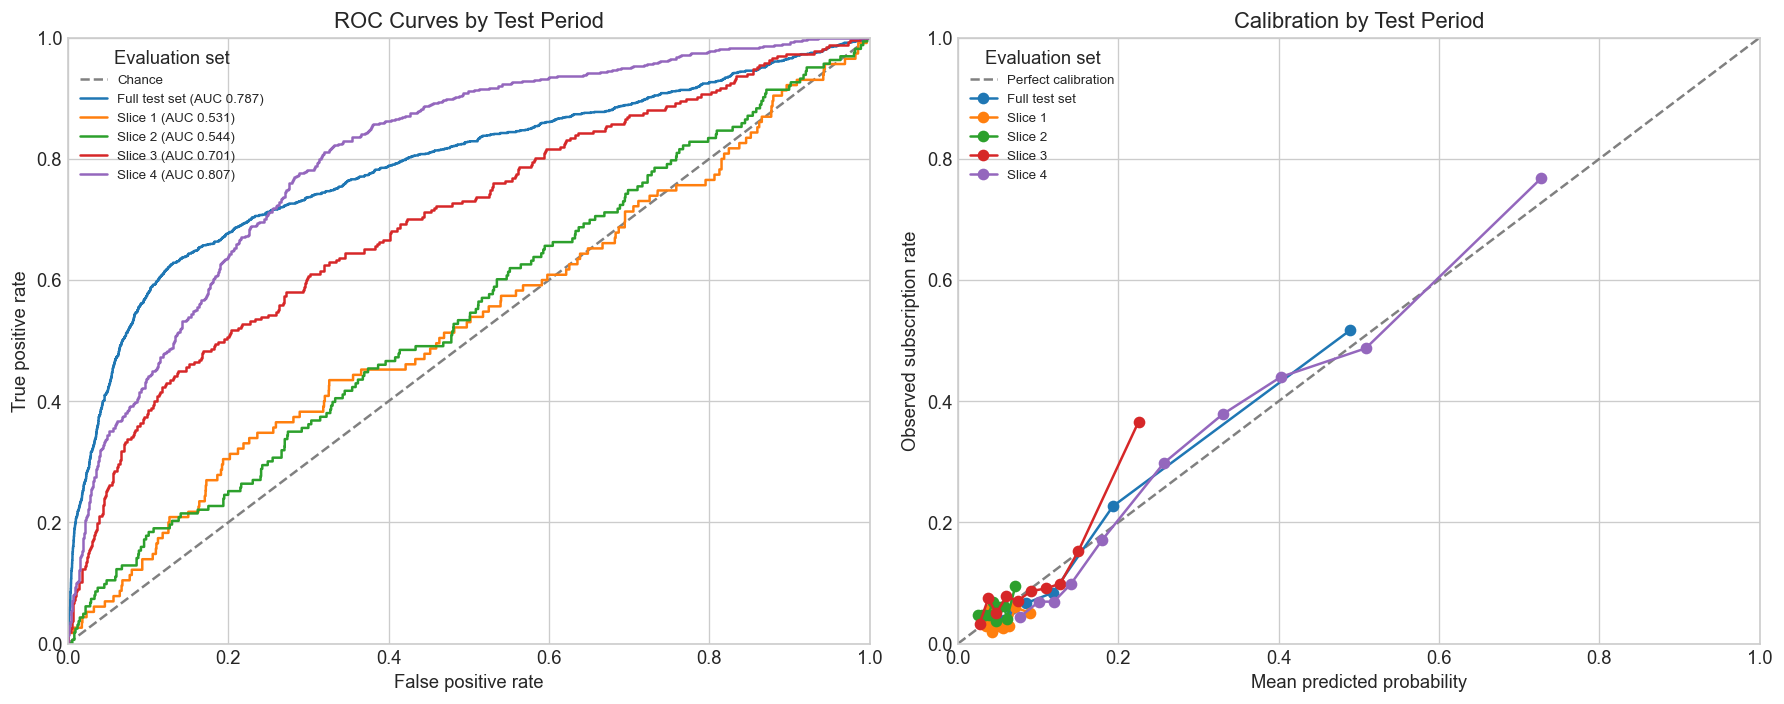

In [47]:
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

excluded_columns = {
    "y",
    "subscribed",
    "campaign",
    "contact",
    "duration",
    "month",
    "month_numeric",
    "day",
    "year",
    "year_month",
}
feature_columns = [column for column in bank.columns if column not in excluded_columns]
features = bank[feature_columns]
target = bank["subscribed"]

numeric_columns = features.select_dtypes(include=np.number).columns.tolist()
categorical_columns = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_columns,
        ),
    ]
)

lift_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)

train_indices, test_indices = train_test_split(
    np.arange(len(bank)),
    test_size=0.25,
    random_state=622,
    stratify=target,
)
lift_model.fit(features.iloc[train_indices], target.iloc[train_indices])

test_results = bank.iloc[test_indices][["year_month", "subscribed"]].copy()
test_results["predicted_probability"] = lift_model.predict_proba(
    features.iloc[test_indices]
)[:, 1]

test_results["slice"] = pd.qcut(
    test_results["year_month"].astype("int64"),
    q=4,
    labels=False,
    duplicates="drop",
).map(lambda code: f"Slice {int(code) + 1}")
slice_names = sorted(test_results["slice"].unique(), key=lambda name: int(name.split()[-1]))
evaluation_groups = [("Full test set", test_results)] + [
    (slice_name, test_results.loc[test_results["slice"] == slice_name])
    for slice_name in slice_names
]

diagnostic_rows = []
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Chance")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Perfect calibration")

for group_name, group in evaluation_groups:
    actual = group["subscribed"].to_numpy()
    probabilities = group["predicted_probability"].to_numpy()
    predictions = probabilities >= 0.5
    fpr, tpr, _ = roc_curve(actual, probabilities)
    observed_rate, mean_probability = calibration_curve(
        actual,
        probabilities,
        n_bins=10,
        strategy="quantile",
    )
    diagnostic_rows.append(
        {
            "evaluation_slice": group_name,
            "test_size": len(group),
            "time_period": f"{group['year_month'].min():%Y-%m} to {group['year_month'].max():%Y-%m}",
            "subscription_rate": actual.mean(),
            "error_rate_at_0.5": np.mean(predictions != actual),
            "roc_auc": roc_auc_score(actual, probabilities),
            "brier_score": brier_score_loss(actual, probabilities),
        }
    )
    axes[0].plot(fpr, tpr, label=f"{group_name} (AUC {roc_auc_score(actual, probabilities):.3f})")
    axes[1].plot(mean_probability, observed_rate, marker="o", label=group_name)

model_diagnostics = pd.DataFrame(diagnostic_rows)
display(
    model_diagnostics.style.format(
        {
            "subscription_rate": "{:.1%}",
            "error_rate_at_0.5": "{:.1%}",
            "roc_auc": "{:.3f}",
            "brier_score": "{:.3f}",
        }
    )
)
axes[0].set(title="ROC Curves by Test Period", xlabel="False positive rate", ylabel="True positive rate", xlim=(0, 1), ylim=(0, 1))
axes[1].set(title="Calibration by Test Period", xlabel="Mean predicted probability", ylabel="Observed subscription rate", xlim=(0, 1), ylim=(0, 1))
for axis in axes:
    axis.legend(title="Evaluation set", fontsize=8)
plt.tight_layout()
plt.show()

**How to read the ROC and calibration plots**

In the left plot, the vertical axis is the share of subscribers the model correctly ranks above the threshold, and the horizontal axis is the share of nonsubscribers it incorrectly flags. Curves nearer the upper left indicate stronger ranking. The dashed diagonal is chance level. Slice 1 and Slice 2 are close to chance, with AUC values of 0.531 and 0.544. Slice 4 ranks best, with an AUC of 0.807. The full test set has an AUC of 0.787.

In the right plot, the horizontal axis is the mean predicted probability within a group of leads, and the vertical axis is the observed subscription rate for that group. The dashed diagonal represents perfect calibration: for example, leads assigned a 20% probability would subscribe about 20% of the time. Points near the line indicate probabilities that match observed rates. AUC describes ranking across thresholds; calibration describes whether the probabilities themselves are trustworthy.

,evaluation_slice,test_size,time_period,baseline_rate,top_10_leads,top_10_hit_rate,top_10_lift,top_50_leads,top_50_hit_rate,top_50_lift
0,Full test set,11303,2008-05 to 2010-11,11.7%,1131,51.7%,4.42x,5652,19.0%,1.63x
1,Slice 1,3180,2008-05 to 2008-06,3.6%,318,5.0%,1.39x,1590,3.8%,1.06x
2,Slice 2,2944,2008-07 to 2008-08,5.5%,295,9.5%,1.71x,1472,5.9%,1.07x
3,Slice 3,2426,2008-10 to 2009-04,11.0%,243,36.6%,3.33x,1213,15.9%,1.45x
4,Slice 4,2753,2009-05 to 2010-11,28.2%,276,76.8%,2.72x,1377,47.4%,1.68x


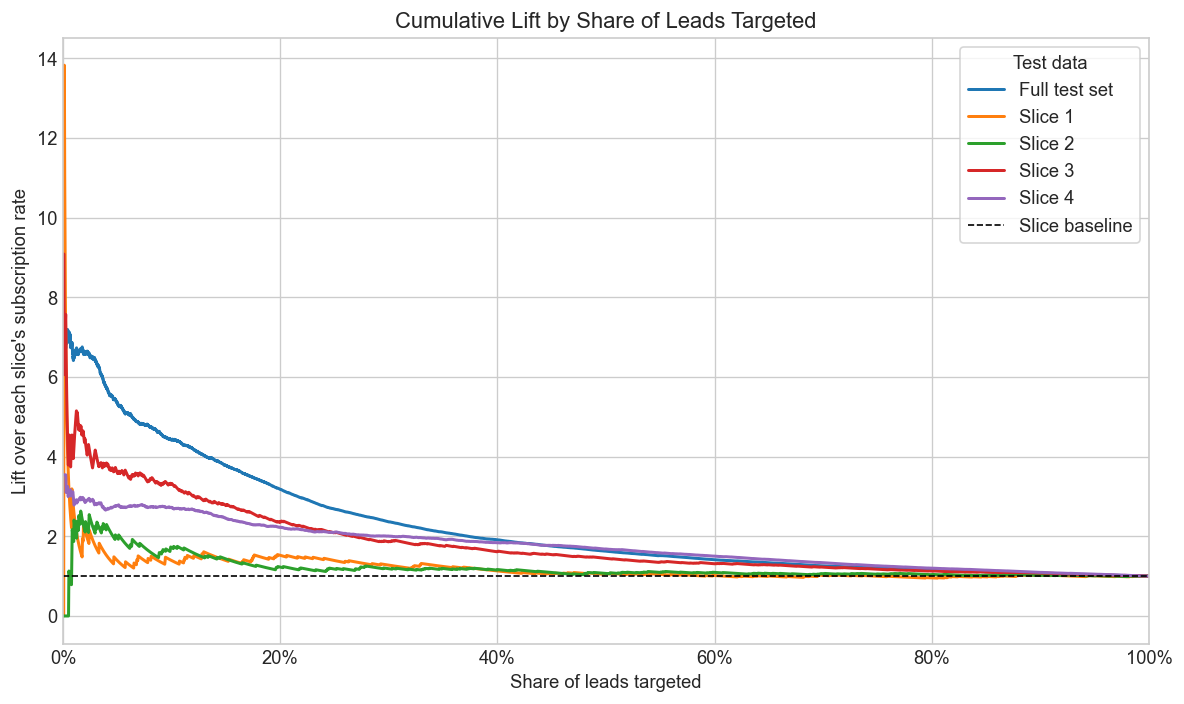

In [48]:
from matplotlib.ticker import PercentFormatter

metric_rows = []
lift_curves = []
for group_name, group in evaluation_groups:
    baseline_rate = group["subscribed"].mean()
    ranked = group.sort_values("predicted_probability", ascending=False).copy()
    row = {
        "evaluation_slice": group_name,
        "test_size": len(ranked),
        "time_period": f"{ranked['year_month'].min():%Y-%m} to {ranked['year_month'].max():%Y-%m}",
        "baseline_rate": baseline_rate,
    }

    for fraction, label in [(0.10, "top_10"), (0.50, "top_50")]:
        top_count = max(1, int(np.ceil(fraction * len(ranked))))
        hit_rate = ranked["subscribed"].iloc[:top_count].mean()
        row[f"{label}_leads"] = top_count
        row[f"{label}_hit_rate"] = hit_rate
        row[f"{label}_lift"] = hit_rate / baseline_rate if baseline_rate > 0 else np.nan

    metric_rows.append(row)
    positions = np.arange(1, len(ranked) + 1)
    ranked["targeted_share"] = positions / len(ranked)
    ranked["cumulative_hit_rate"] = ranked["subscribed"].cumsum() / positions
    ranked["lift"] = ranked["cumulative_hit_rate"] / baseline_rate
    ranked["evaluation_slice"] = group_name
    lift_curves.append(ranked[["targeted_share", "lift", "evaluation_slice"]])

lift_metrics = pd.DataFrame(metric_rows)
display(
    lift_metrics.style.format(
        {
            "baseline_rate": "{:.1%}",
            "top_10_hit_rate": "{:.1%}",
            "top_10_lift": "{:.2f}x",
            "top_50_hit_rate": "{:.1%}",
            "top_50_lift": "{:.2f}x",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 6))
for curve in lift_curves:
    ax.plot(
        curve["targeted_share"],
        curve["lift"],
        label=curve["evaluation_slice"].iloc[0],
        linewidth=1.8,
    )
ax.axhline(1, color="black", linestyle="--", linewidth=1, label="Slice baseline")
ax.set(
    title="Cumulative Lift by Share of Leads Targeted",
    xlabel="Share of leads targeted",
    ylabel="Lift over each slice's subscription rate",
    xlim=(0, 1),
)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.legend(title="Test data", frameon=True)
plt.tight_layout()
plt.show()

**How to read the lift plot**

The horizontal axis is the share of leads selected, starting with the highest predicted probabilities. The vertical axis is cumulative lift: the subscription rate among selected leads divided by the overall rate for that same test group. The dashed line at 1 means the selected group performs at its baseline rate. A curve above 1 means the ranking finds subscribers more often than selecting leads without using the scores. At 100% of leads, every curve returns to 1 because the selected group is then the whole test group.

## Problem 4: How Has the Marketing Team Already Been Optimizing?

### 4a. Data Generating Process

The records suggest repeated targeting. In 18.3% of the 45,211 records, the client had at least one earlier campaign contact. Prior campaign outcome is strongly associated with subscription: 64.7% of clients with a prior successful campaign subscribed, compared with 9.2% among clients whose prior outcome is unknown. This pattern is consistent with the team exploiting information from earlier responses, while contacting clients with no recorded history may provide some exploration.

The yearly profile table adds evidence of changing contact history. The share with a previous contact rises from 3.3% in 2008 to 37.8% in 2009 and 65.7% in the partial 2010 sample. The share with a prior campaign success rises from 0.2% to 4.8% and 28.7%. This could reflect increased exploitation of leads with known successful histories. It could also reflect changes in the dataset, campaign timing, or recording practices, so it is evidence consistent with a changing strategy rather than proof of one.

The number of contacts in the current campaign also varies. Subscription rates fall from 14.6% among clients contacted once to 6.4% among those contacted five or more times. This does not show that repeated calls reduce success: clients may receive more calls because they did not respond earlier. The prior outcome and contact counts are evidence of different contact histories, not proof of a causal strategy. The changing call volume and subscription rates over time may reflect both strategy and the economic conditions recorded in the data.

The dataset includes contacted clients, not the full pool of eligible leads. It therefore cannot reveal who the team chose not to call or establish how likely those people were to subscribe without contact. A model trained on these records estimates response among the observed contacted clients, not the effect of calling any lead. The contact count for the current campaign is only known after contacts occur, so it should not be used as a targeting feature.

### 4b. Who Isn't Called?

A complete lead table would include eligible people whether or not the bank contacted them, with the same information available before a call. The bank should record contact assignment, channel, timing, cost, and subscription outcomes over a consistent follow up period for both contacted and uncontacted leads. A small randomized no contact group, or recorded probabilities of contact assignment, would help separate subscriptions caused by outreach from subscriptions that would have happened anyway.

With those data, the team could estimate which groups gain the most from a call, find promising leads that past practices overlooked, and compare the extra subscriptions with the cost of outreach. That supports decisions based on incremental benefit rather than simply ranking people who are already likely to subscribe.

In [49]:
campaign_groups = pd.Series(
    np.where(bank["campaign"] >= 5, "5+", bank["campaign"].astype(str)),
    index=bank.index,
    name="campaign_group",
)
campaign_order = ["1", "2", "3", "4", "5+"]
campaign_summary = (
    bank.assign(campaign_group=campaign_groups)
    .groupby("campaign_group", observed=True)
    .agg(
        clients=("subscribed", "size"),
        subscription_rate=("subscribed", "mean"),
        average_contacts=("campaign", "mean"),
    )
    .reindex(campaign_order)
)

prior_outcome_summary = bank.groupby("poutcome", dropna=False).agg(
    clients=("subscribed", "size"),
    subscription_rate=("subscribed", "mean"),
)

contact_type_summary = bank.groupby("contact", dropna=False).agg(
    clients=("subscribed", "size"),
    subscription_rate=("subscribed", "mean"),
)

prior_contact_count = int(bank["previous"].gt(0).sum())
print(
    f"Clients with at least one earlier campaign contact: "
    f"{prior_contact_count:,} of {len(bank):,} "
    f"({prior_contact_count / len(bank):.1%})"
)
print("Current campaign contact count:")
display(campaign_summary.style.format({"subscription_rate": "{:.1%}", "average_contacts": "{:.2f}"}))
print("Previous campaign outcome:")
display(prior_outcome_summary.style.format({"subscription_rate": "{:.1%}"}))
print("Contact channel:")
display(contact_type_summary.style.format({"subscription_rate": "{:.1%}"}))

Clients with at least one earlier campaign contact: 8,257 of 45,211 (18.3%)
Current campaign contact count:


,clients,subscription_rate,average_contacts
campaign_group,,,
1,17544,14.6%,1.00
2,12505,11.2%,2.00
3,5521,11.2%,3.00
4,3522,9.0%,4.00
5+,6119,6.4%,8.46


Previous campaign outcome:


,clients,subscription_rate
poutcome,,
failure,4901,12.6%
other,1840,16.7%
success,1511,64.7%
unknown,36959,9.2%


Contact channel:


,clients,subscription_rate
contact,,
cellular,29285,14.9%
telephone,2906,13.4%
unknown,13020,4.1%
